### Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn import metrics
from xgboost import XGBRegressor

In [3]:
import warnings
warnings.filterwarnings('ignore')

### Step 2: Load Dataset

In [52]:
df = pd.read_csv('./data/boxoffice.csv')

In [53]:
df.shape

(2694, 10)

In [54]:
df.head()

,title,domestic_revenue,world_revenue,distributor,opening_revenue,opening_theaters,budget,MPAA,genres,release_days
0,The Avengers,6026491,1274885664,Warner Bros.,163620146,253,174687337,R,Animation,16
1,Titanic,169411543,1132871091,Disney,85549990,122,103948486,G,Action,103
2,Jurassic Park,107836098,583329845,Sony,55681429,3826,122104991,NC-17,Horror,89
3,Avatar,51433697,1225323391,Disney,109775324,3868,46431596,G,Horror,85
4,The Lion King,142791649,604140729,Warner Bros.,59476800,2934,203513696,R,Comedy,158


### Step 3: Exploring Data

In [55]:
df.describe()

,domestic_revenue,world_revenue,opening_revenue,opening_theaters,budget,release_days
count,2.694000e+03,2.694000e+03,2.694000e+03,2694.000000,2.694000e+03,2694.000000
mean,1.508539e+08,7.719177e+08,9.971321e+07,2263.039347,1.537996e+08,90.897550
std,8.579997e+07,4.284414e+08,5.721762e+07,1298.559140,8.557624e+07,50.894041
min,8.277650e+05,3.261301e+06,1.385690e+05,10.000000,5.197977e+06,1.000000
25%,7.673272e+07,3.991135e+08,5.033848e+07,1161.000000,7.861876e+07,47.000000
50%,1.525725e+08,7.665551e+08,9.981418e+07,2271.500000,1.562567e+08,91.000000
75%,2.247314e+08,1.143920e+09,1.489805e+08,3392.250000,2.274832e+08,135.000000
max,2.998107e+08,1.499310e+09,1.999336e+08,4499.000000,2.998597e+08,179.000000


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2694 entries, 0 to 2693
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   title             2694 non-null   object
 1   domestic_revenue  2694 non-null   int64 
 2   world_revenue     2694 non-null   int64 
 3   distributor       2694 non-null   object
 4   opening_revenue   2694 non-null   int64 
 5   opening_theaters  2694 non-null   int64 
 6   budget            2694 non-null   int64 
 7   MPAA              2694 non-null   object
 8   genres            2694 non-null   object
 9   release_days      2694 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 210.6+ KB


In [57]:
df.isnull().sum()

title               0
domestic_revenue    0
world_revenue       0
distributor         0
opening_revenue     0
opening_theaters    0
budget              0
MPAA                0
genres              0
release_days        0
dtype: int64

<Axes: xlabel='count', ylabel='MPAA'>

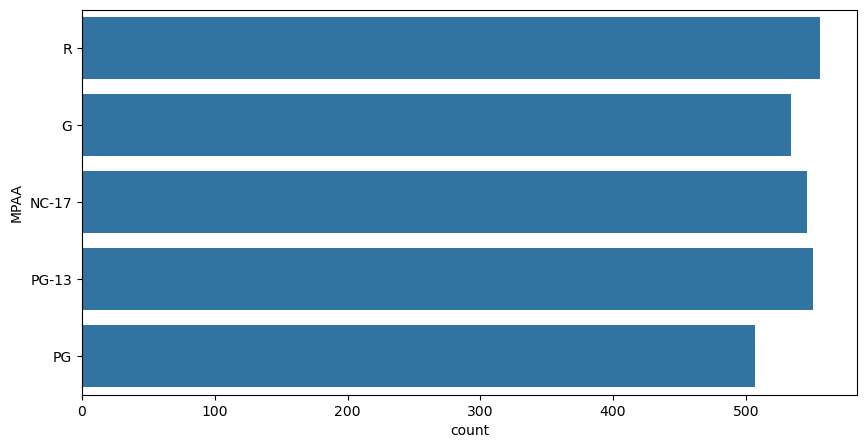

In [58]:
plt.figure(figsize=(10, 5))
sns.countplot(df['MPAA'])

In [59]:
df.groupby('MPAA')['domestic_revenue'].mean()

MPAA
G        1.465288e+08
NC-17    1.507193e+08
PG       1.529123e+08
PG-13    1.477556e+08
R        1.563334e+08
Name: domestic_revenue, dtype: float64

In [60]:
features = ['domestic_revenue', 'opening_theaters', 'release_days']

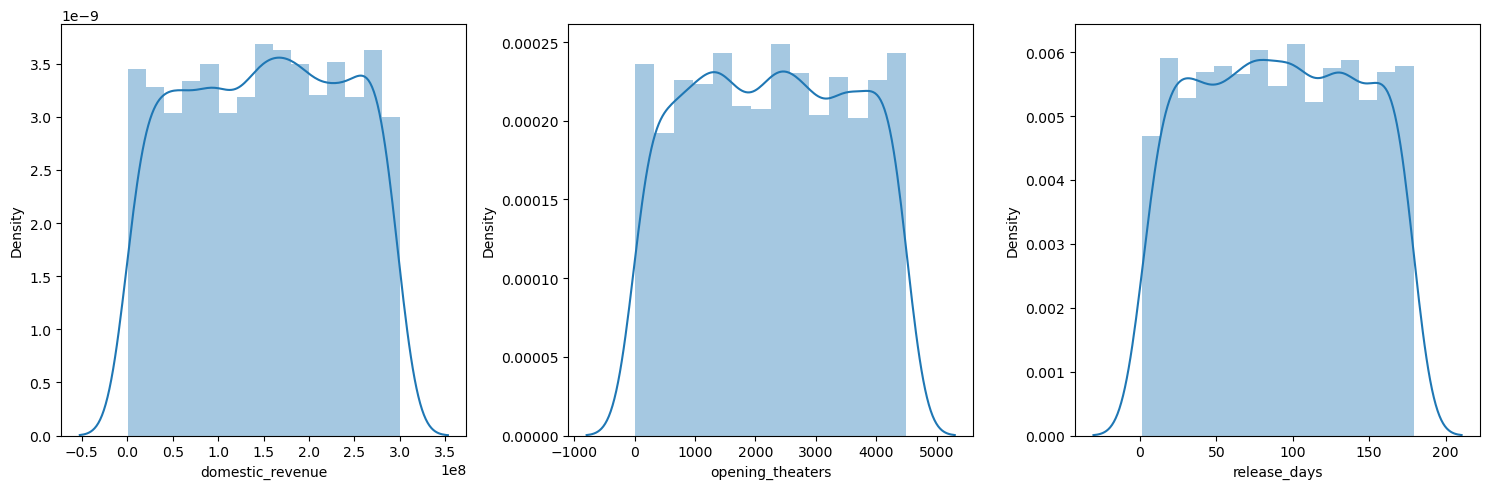

In [61]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.distplot(df[col])
plt.tight_layout()

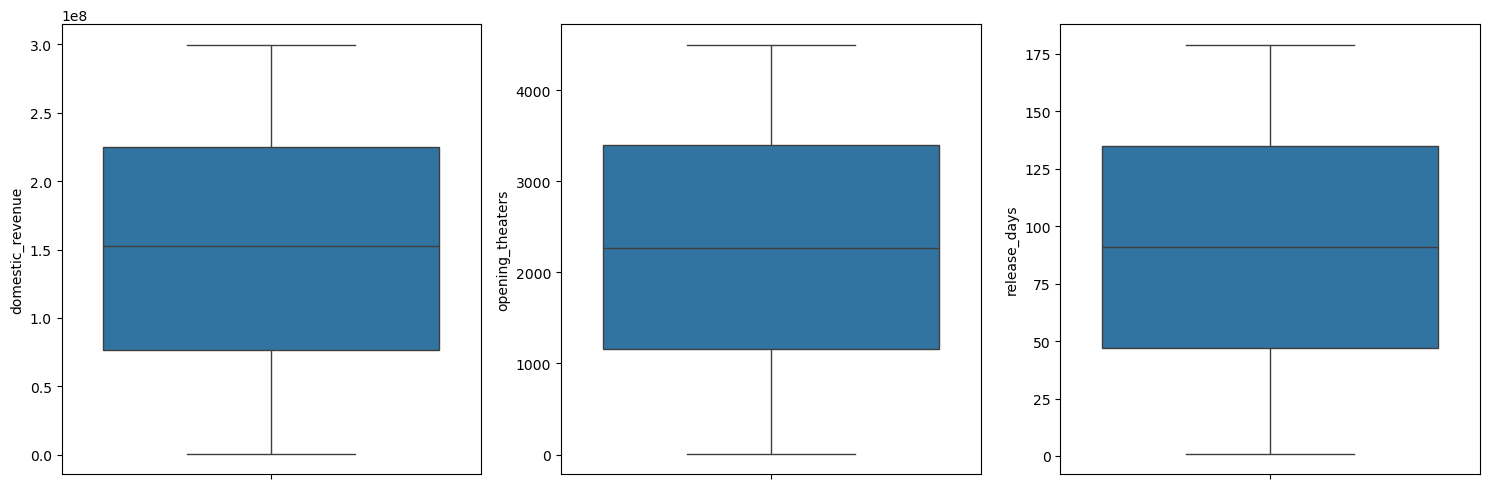

In [62]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(df[col])
plt.tight_layout()

### Step 4: Feature Engineering

In [63]:
for col in features:
    df[col] = df[col].apply(lambda x: np.log10(x))

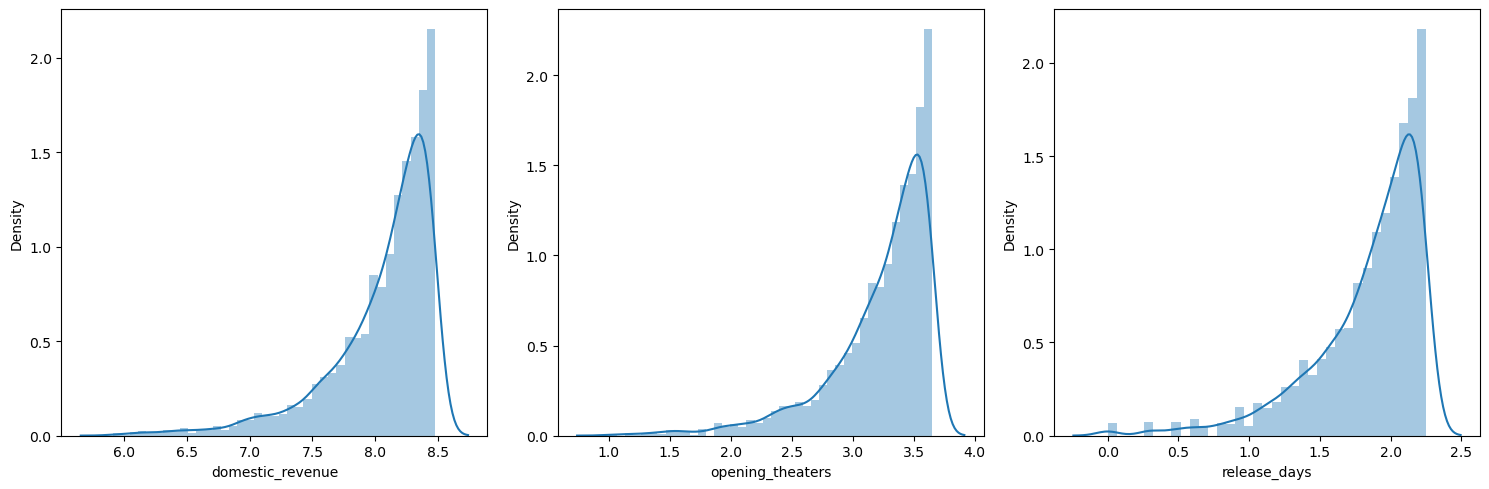

In [64]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.distplot(df[col])
plt.tight_layout()

In [69]:
df = pd.concat([df, pd.get_dummies(df['genres'], dtype=pd.Int32Dtype)], axis=1)

In [70]:
for col in ['distributor', 'MPAA']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

<Axes: >

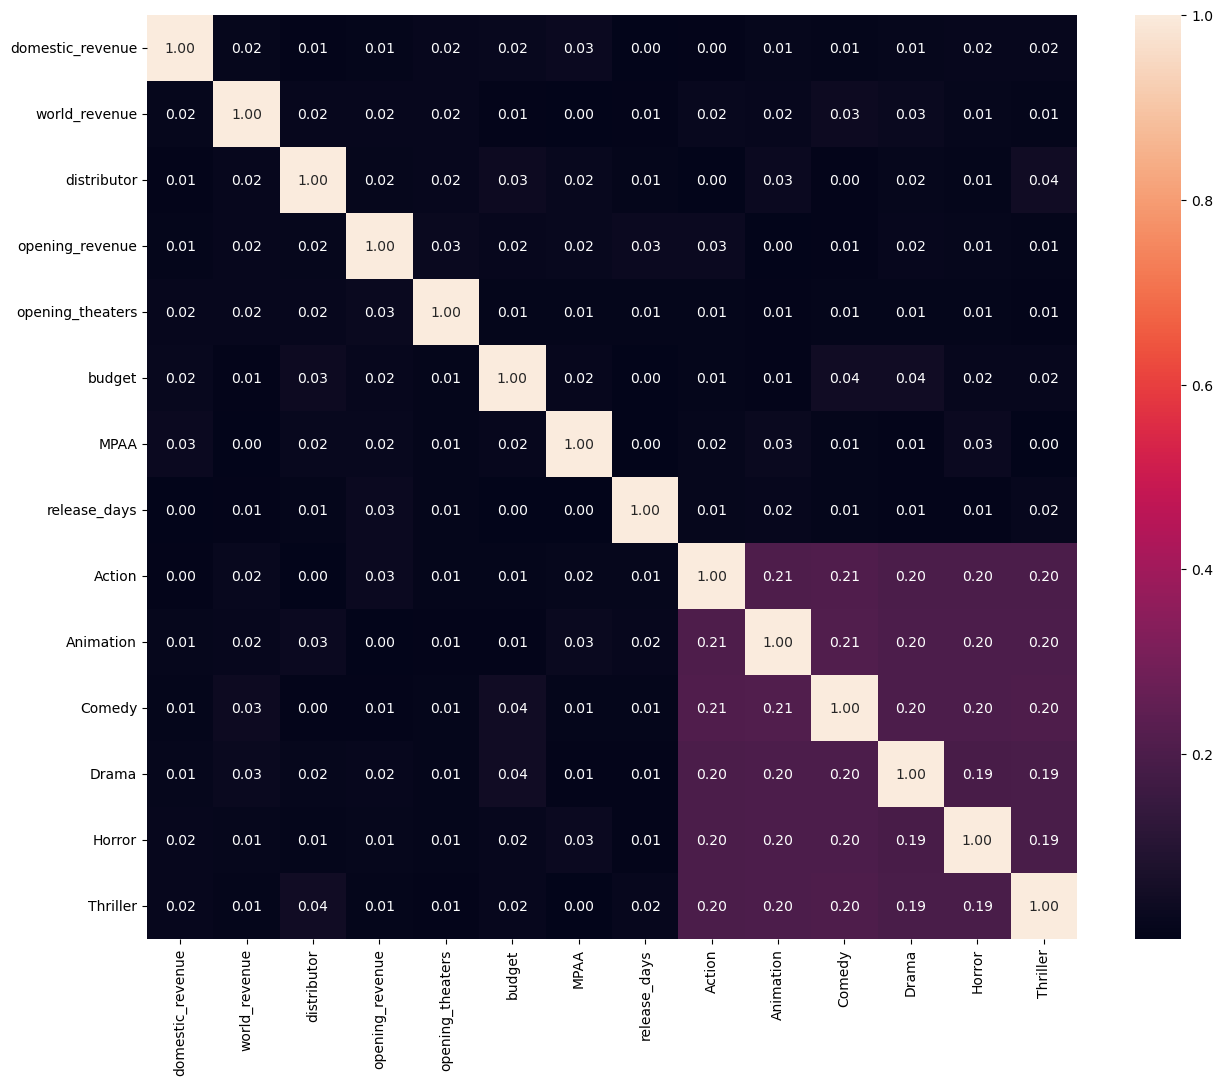

In [71]:
plt.figure(figsize=(15, 12))
sns.heatmap(
    df.select_dtypes(np.number).corr().abs(),
    annot=True,
    fmt='.2f'
)

### Step 4: Preparing Data

In [72]:
features = df.drop(['world_revenue', 'opening_revenue', 'genres', 'budget', 'title', 'domestic_revenue'], axis=1)
target = df['domestic_revenue'].values

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [74]:
scaler = StandardScaler()

In [75]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Step 5: Training Model

In [76]:
model = XGBRegressor()

In [77]:
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Step 6: Evaluate Model

In [78]:
train_preds = model.predict(X_train) 
print('Training Error : ', metrics.mean_absolute_error(y_train, train_preds)) 

test_preds = model.predict(X_test) 
print('Validation Error : ', metrics.mean_absolute_error(y_test, test_preds)) 

Training Error :  0.10436612930422594
Validation Error :  0.3654947630903561
